<a href="https://www.kaggle.com/code/mennaezzelarab/water-segmentation-transferlearning-task-2-sub?scriptVersionId=301938670" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Setup and Environment

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import segmentation_models_pytorch as smp

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Pipeline (85/15 Split)

In [5]:
class WaterDataset(Dataset):
    def __init__(self, image_paths, label_paths):
        self.image_paths = sorted(image_paths)
        self.label_paths = sorted(label_paths)
        self.valid_pairs = []
        
        label_map = {os.path.splitext(os.path.basename(p))[0]: p for p in self.label_paths}
        for img_p in self.image_paths:
            img_name = os.path.splitext(os.path.basename(img_p))[0]
            if img_name in label_map:
                self.valid_pairs.append((img_p, label_map[img_name]))

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_path, lbl_path = self.valid_pairs[idx]
        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)
        label = np.array(Image.open(lbl_path)).astype(np.float32)
        if len(label.shape) == 3: label = label[:,:,0]
        label = (label > 0).astype(np.float32)
        return torch.from_numpy(image), torch.from_numpy(label).unsqueeze(0)

class NormalizedWaterDataset(Dataset):
    def __init__(self, base_dataset, mean, std):
        self.base_dataset = base_dataset
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)
    def __len__(self): return len(self.base_dataset)
    def __getitem__(self, idx):
        img, lbl = self.base_dataset[idx]
        img = (img - self.mean) / (self.std + 1e-8)
        return img, lbl

In [6]:
MEAN = [ 395.3473,  493.9571,  815.2462,  955.2073, 2068.3069, 1949.9069,
        1333.5028,  103.6337,  114.8657,  327.6829,   34.9512,    9.7407]
STD = [ 283.5301,  334.6441,  420.5426,  578.0315, 1055.7791, 1171.2211,
     925.1953,   49.8946, 1558.2714,  494.9977,   20.1714,   27.8250]

dataset_path = "/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data"

image_paths = glob.glob(os.path.join(dataset_path, "images", "*.tif"))
label_paths = glob.glob(os.path.join(dataset_path, "labels", "*.png"))

In [7]:
# Split: 85% Train, 15% Test
train_imgs, test_imgs = train_test_split(image_paths, test_size=0.15, random_state=42)

train_loader = DataLoader(NormalizedWaterDataset(WaterDataset(train_imgs, label_paths), MEAN, STD), batch_size=8, shuffle=True)
test_loader = DataLoader(NormalizedWaterDataset(WaterDataset(test_imgs, label_paths), MEAN, STD), batch_size=8, shuffle=False)

print(f"Data ready: {len(train_imgs)} training samples, {len(test_imgs)} test samples.")

Data ready: 260 training samples, 46 test samples.


# Training

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        inter = (p * t).sum()
        return 1 - ((2. * inter + self.smooth) / (p.sum() + t.sum() + self.smooth))

def get_metrics(model, loader, device, threshold=0.5):
    model.eval()
    all_iou, all_f1, all_prec, all_rec = [], [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).squeeze(1)
            outputs = torch.sigmoid(model(imgs).squeeze(1))
            preds = (outputs > threshold).float()
            
            # Intersection, Union, TP, FP, FN
            intersection = (preds * labels).sum()
            union = (preds + labels).sum() - intersection
            tp = (preds * labels).sum()
            fp = (preds * (1 - labels)).sum()
            fn = ((1 - preds) * labels).sum()
            
            all_iou.append(((intersection + 1e-8) / (union + 1e-8)).item())
            all_f1.append(((2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)).item())
            all_prec.append(((tp + 1e-8) / (tp + fp + 1e-8)).item())
            all_rec.append(((tp + 1e-8) / (tp + fn + 1e-8)).item())
            
    return np.mean(all_iou), np.mean(all_f1), np.mean(all_prec), np.mean(all_rec)

def train_model(model, name, train_loader, test_loader, device):
    print(f"\n--- Training {name} ---")
    
    # Stage 1: BCE (100 Epochs)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))
    print("Stage 1 (BCE)...")
    for epoch in range(100):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls.squeeze(1))
            loss.backward(); optimizer.step()
        if (epoch+1) % 25 == 0: print(f"Epoch {epoch+1}/100 complete")

    # Stage 2: Dice Fine-tuning (50 Epochs)
    optimizer = optim.Adam(model.parameters(), lr=5e-5)
    criterion = DiceLoss()
    print("Stage 2 (Dice)...")
    for epoch in range(50):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls.squeeze(1))
            loss.backward(); optimizer.step()
            
    # Final Metrics
    metrics = get_metrics(model, test_loader, device)
    print(f"Final Test Metrics for {name}:")
    print(f"IoU: {metrics[0]:.4f} | F1: {metrics[1]:.4f} | Prec: {metrics[2]:.4f} | Rec: {metrics[3]:.4f}")
    torch.save(model.state_dict(), f"final_{name.replace(' ', '_')}.pth")
    return metrics

In [9]:
models_to_train = {
    "UNet_ResNet34": smp.Unet(encoder_name="resnet34", encoder_weights='imagenet', in_channels=12, classes=1),
    "DeepLabV3+_ResNet50": smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights='imagenet', in_channels=12, classes=1)
}

results = {}
for name, model in models_to_train.items():
    results[name] = train_model(model.to(device), name, train_loader, test_loader, device)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


--- Training UNet_ResNet34 ---
Stage 1 (BCE)...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch 25/100 complete
Epoch 50/100 complete
Epoch 75/100 complete
Epoch 100/100 complete
Stage 2 (Dice)...
Final Test Metrics for UNet_ResNet34:
IoU: 0.8576 | F1: 0.9201 | Prec: 0.9323 | Rec: 0.9096

--- Training DeepLabV3+_ResNet50 ---
Stage 1 (BCE)...
Epoch 25/100 complete
Epoch 50/100 complete
Epoch 75/100 complete
Epoch 100/100 complete
Stage 2 (Dice)...
Final Test Metrics for DeepLabV3+_ResNet50:
IoU: 0.8395 | F1: 0.9100 | Prec: 0.9172 | Rec: 0.9036


# Comparative Summary

In [10]:
print("\n" + "="*50)
print(f"{'Model Name':<25} | {'IoU':<8} | {'F1-Score':<8}")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name:<25} | {metrics[0]:<8.4f} | {metrics[1]:<8.4f}")
print("="*50)


Model Name                | IoU      | F1-Score
--------------------------------------------------
UNet_ResNet34             | 0.8576   | 0.9201  
DeepLabV3+_ResNet50       | 0.8395   | 0.9100  


# Visualization

In [11]:
def visualize_results(dataset, model_path, arch, device, indices=[2, 7, 12, 15]):
    # Re-init model for visualization
    if "UNet" in arch:
        model = smp.Unet(encoder_name="resnet34", encoder_weights='imagenet', in_channels=12, classes=1)
    else:
        model = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights='imagenet', in_channels=12, classes=1)
    
    model.load_state_dict(torch.load(model_path))
    model.to(device).eval()
    
    fig, axs = plt.subplots(len(indices), 3, figsize=(12, len(indices)*4))
    for i, idx in enumerate(indices):
        img_tensor, label_tensor = dataset[idx]
        with torch.no_grad():
            output = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)).squeeze())
            pred_mask = (output > 0.5).cpu().numpy()
        
        # RGB Reconstruction (3,2,1)
        rgb = img_tensor[[3,2,1],:,:].cpu().numpy()
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        
        axs[i,0].imshow(np.transpose(rgb, (1,2,0))); axs[i,0].set_title(f"Test Sample {idx} (RGB)")
        axs[i,1].imshow(label_tensor.squeeze().numpy(), cmap='Blues'); axs[i,1].set_title("Ground Truth")
        axs[i,2].imshow(pred_mask, cmap='Blues'); axs[i,2].set_title(f"Prediction ({arch})")
        for ax in axs[i]: ax.axis('off')
    
    plt.tight_layout()
    plt.show()


Winning Model: UNet_ResNet34. Generating final visual grids...


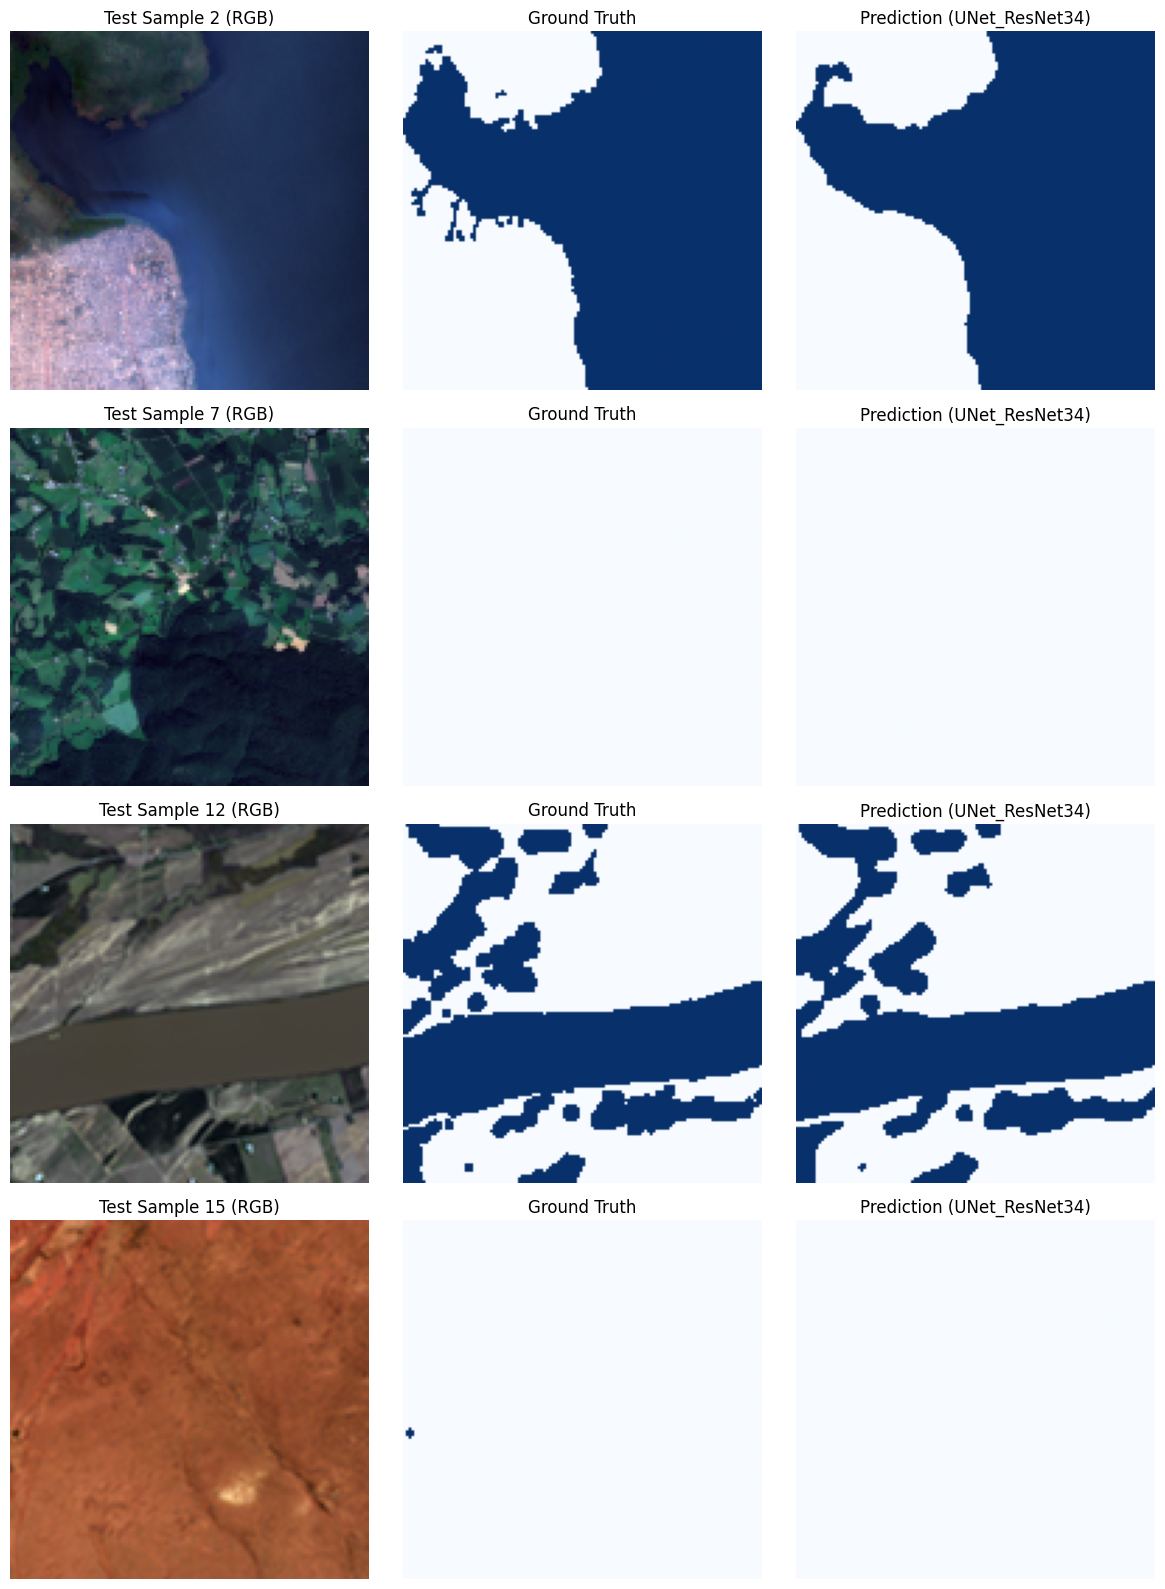

In [12]:
winner_name = max(results, key=lambda x: results[x][0])
print(f"\nWinning Model: {winner_name}. Generating final visual grids...")
visualize_results(test_loader.dataset, f"final_{winner_name.replace(' ', '_')}.pth", winner_name, device)